# 📊 Análise Exploratória de Dados (EDA) — Case NPS
**Fase 01 — AI Scientist**

O objetivo deste notebook é investigar as variáveis operacionais e a jornada de compra para entender os fatores que mais impactam o Net Promoter Score (NPS) do e-commerce. O foco é mapear os "pontos de ruptura" na experiência do cliente, criando uma base sólida para a posterior modelagem preditiva.

## 1. Setup e Qualidade dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='darkgrid', palette='muted')

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Carregamento dos dados brutos
CAMINHO_CSV = '../data/raw/desafio_nps_fase_1.csv'
df = pd.read_csv(CAMINHO_CSV)

display(df.head())
print(f'\nTotal de linhas e colunas: {df.shape}')
print(f'Total de valores nulos no dataset: {df.isnull().sum().sum()}')

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9



Total de linhas e colunas: (2500, 19)
Total de valores nulos no dataset: 0


## 2. O Alvo (NPS) e o Perfil do Cliente

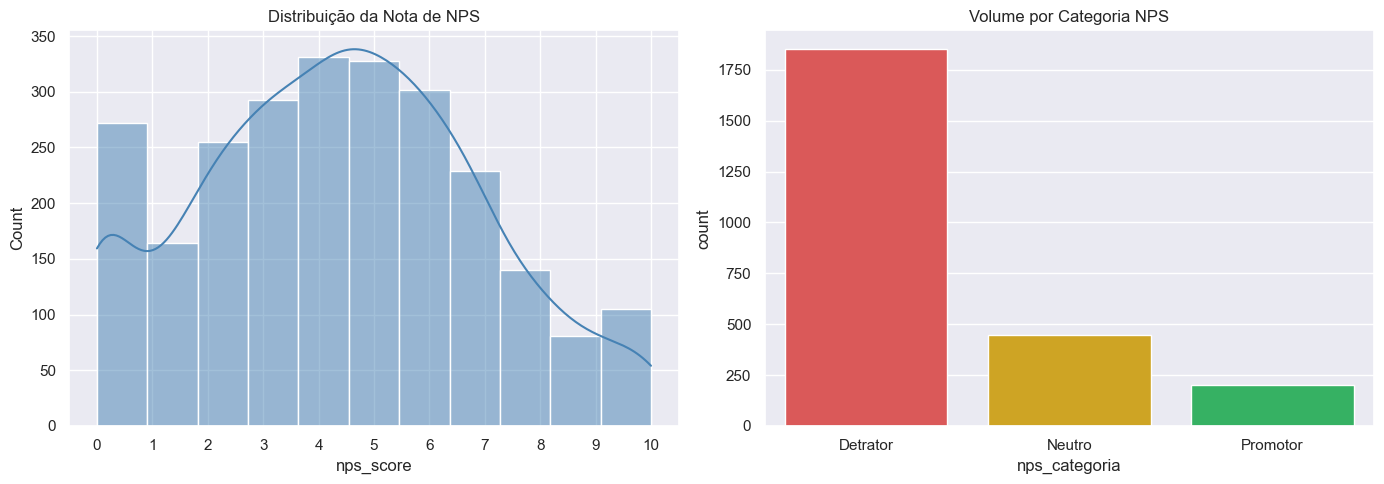

In [4]:
# Classificação NPS Oficial
def classificar_nps(score):
    if score <= 6: return 'Detrator'
    elif score <= 8: return 'Neutro'
    else: return 'Promotor'

df['nps_categoria'] = df['nps_score'].apply(classificar_nps)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['nps_score'], bins=11, kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('Distribuição da Nota de NPS')
ax[0].set_xticks(range(0, 11))

sns.countplot(data=df, x='nps_categoria', order=['Detrator', 'Neutro', 'Promotor'], ax=ax[1], palette=['#ef4444', '#eab308', '#22c55e'])
ax[1].set_title('Volume por Categoria NPS')

plt.tight_layout()
plt.show()

## 3. Investigando os Pontos de Ruptura
Nesta etapa, avaliamos o NPS contra os principais atritos da jornada (atrasos, contatos com o SAC e reclamações) para identificar em qual momento exato a experiência do cliente é comprometida.

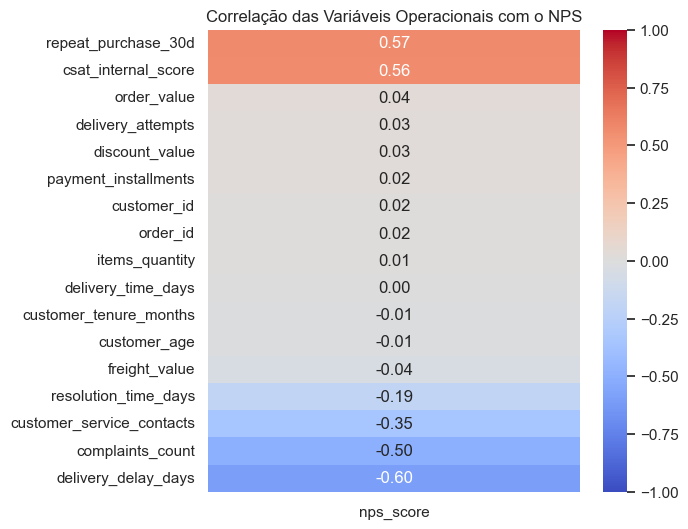

In [5]:
# Correlação direta com a variável target
colunas_numericas = df.select_dtypes(include=[np.number]).columns
correlacao = df[colunas_numericas].corr()[['nps_score']].sort_values(by='nps_score', ascending=False)

plt.figure(figsize=(6, 6))
sns.heatmap(correlacao.drop('nps_score'), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlação das Variáveis Operacionais com o NPS')
plt.show()

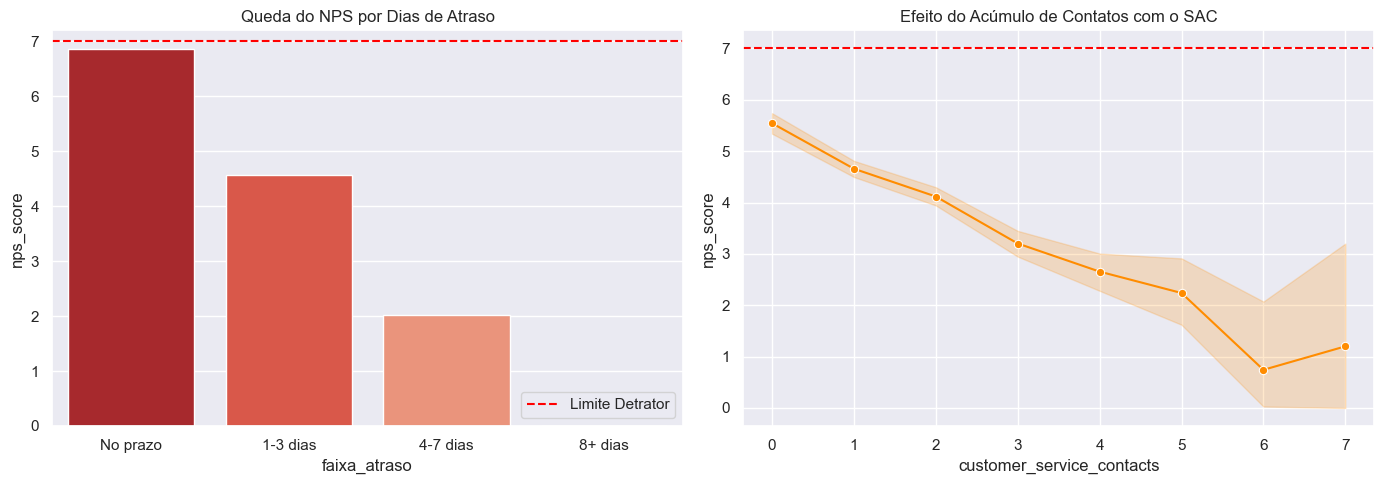

In [6]:
# Ponto de Ruptura: Atraso de Entrega e Contatos no SAC
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Criação dinâmica de faixas de atraso
df['faixa_atraso'] = pd.cut(df['delivery_delay_days'], bins=[-1, 0, 3, 7, 100], labels=['No prazo', '1-3 dias', '4-7 dias', '8+ dias'])
sns.barplot(data=df, x='faixa_atraso', y='nps_score', ax=ax[0], palette='Reds_r', errorbar=None)
ax[0].set_title('Queda do NPS por Dias de Atraso')
ax[0].axhline(7, color='red', linestyle='--', label='Limite Detrator')
ax[0].legend()

sns.lineplot(data=df, x='customer_service_contacts', y='nps_score', marker='o', ax=ax[1], color='darkorange')
ax[1].set_title('Efeito do Acúmulo de Contatos com o SAC')
ax[1].axhline(7, color='red', linestyle='--')

plt.tight_layout()
plt.show()

## 4. O Fator Geográfico
Verificando se a experiência logística e a nota de NPS sofrem variações severas dependendo da região atendida.

In [7]:
nps_regiao = df.groupby('customer_region').agg(
    nps_medio=('nps_score', 'mean'),
    atraso_medio=('delivery_delay_days', 'mean'),
    reclamacoes_media=('complaints_count', 'mean')
).sort_values('nps_medio', ascending=False).reset_index()

# Exibição visual limpa usando o renderizador do Pandas
display(nps_regiao.style.background_gradient(cmap='Blues'))

,customer_region,nps_medio,atraso_medio,reclamacoes_media
0,Sul,4.490979,2.168906,4.061420
1,Nordeste,4.421649,2.185567,4.162887
2,Norte,4.382609,2.144269,4.110672
3,Sudeste,4.373846,2.217308,4.242308
4,Centro-Oeste,4.209829,2.222222,4.177350


## 5. O Impacto no Bolso (Recompra)
Cruzamento final: A nota do Net Promoter Score realmente reflete na retenção deste cliente?

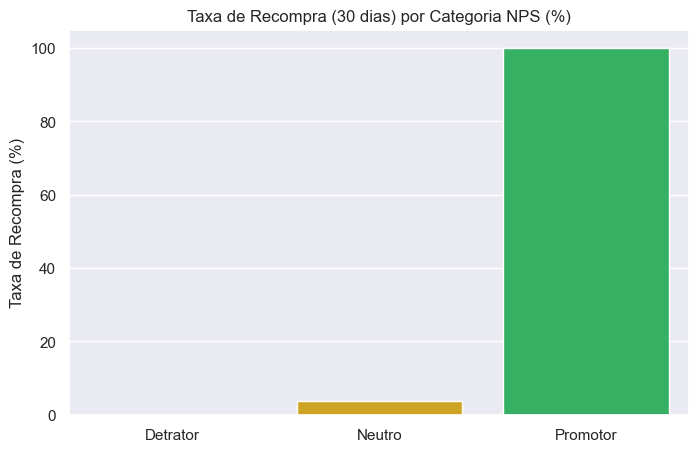

In [8]:
recompra = df.groupby('nps_categoria')['repeat_purchase_30d'].mean() * 100
recompra = recompra.reindex(['Detrator', 'Neutro', 'Promotor']).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=recompra, x='nps_categoria', y='repeat_purchase_30d', palette=['#ef4444', '#eab308', '#22c55e'])
plt.title('Taxa de Recompra (30 dias) por Categoria NPS (%)')
plt.ylabel('Taxa de Recompra (%)')
plt.xlabel('')
plt.show()

## ✅ Conclusão Executiva

1. O perfil de risco foi claramente mapeado. Fatores operacionais como **Atraso na Entrega** e **Volume de Contatos no SAC** são os grandes vilões do NPS.
2. A relação entre um NPS alto e a taxa de retenção financeira (recompra) foi comprovada pelos dados empíricos.
3. **Próximo Passo:** Com o problema de negócio validado na EDA, esses dados limpos alimentarão o pipeline em `src/train.py` para a construção dos modelos definitivos de Machine Learning.